# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum()) # Cantidad de valores nulos)
print(usage.isna().mean()) # Proporción de valores nulos)# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
      En USERS: city (11.7% son nulos) y churn_date (88.3%)
      En USAGE: date (0.12%), duration (55.19%) y lenght (44.7%)
- Indica qué harías: ¿imputar, eliminar, ignorar?
      En USERS: city (ignoraria, el analisis no recquiere la ubicacion) y churn_date (ignoraria, implica que el cliente sigue activo)
      En USAGE: previo a tomar una decisión solo revisaría congruencia entre si falta la duración sea pq es un mensaje, y así mismo si falta lenght que sea pq la operacion sea una llamada. Donde si tomaria una decisión definitiva seria en los 50 nulos de date, no imputaria ya que puedo afectar el1 analisis, solo ignoraria los nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`
  habla de los usuarios y sus IDS, el minimo implica donde comienza el primer usuario y max el ultimo usuario registrado
- La columna `age`
  Contiene sentinels (observado en min: -999), el promedio es de 33 años, siendo la edad maxima registrada de 79 años, y la mediana es de 50 años

In [13]:
usage.describe() #explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` hablan de los registros(id) de las acciones realizados por los usuarios (user_id) ya sea en llamadas o mensajes
- Las columnas `duration` y `lenght` describen la duración de las llamadas y longuitud de los mensajes de texto hechos por los usuarios, siendo respectivamente los promedios: 5 minutos y 52 caracteres, la mediana 3.5 minutos y 50 caracteres, ambas cuentan con un sesgo hacia la derecha (observado en el percentil 75% y el max)

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [15]:
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city`
  El analisis se realiza en clientes localizados en 7 ciudades diferentes. Bogota (repitiendose 808 ocasiones de mas de 3531 registros) es la ciudad que lidera tanto en los planes Premium como Básico. existen 469 nulos, y sentinels como (?)
- La columna `plan`
  No cuenta con nulos, la categoria Basica sobrepasa a Premium, teniendo el registro de 2595 planes y 1405 respectivamente

In [16]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [17]:
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` muestra:
Que la gente envia mas mensajes que lo que realizan llamadas, no hay nulos
  


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? En age (-999), y en city espacio en blanco y signo de interrogacion
- ¿Qué acción tomarías?  Vería cuantas veces se repite dicho valor, considero una mejor opcion reemplazar con la mediana, ya que usar el promedio afectaría mucho, ya que hay una variacion grande entre ambos

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [20]:
# Revisar los años presentes en `reg_date` de users
users['año_registro'] = users['reg_date'].dt.year

In [21]:
print(users['año_registro'].value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: año_registro, dtype: int64


En `reg_date`, 
Se registran fechas desde el 2022 al 2024, y existen registros implosibles (2026 reisgtrado 40 ocasiones)
existe una tendencia similar entre los nuevos registros cada año, ligeramente por encima el año 2024

In [22]:
# Revisar los años presentes en `date` de usage
usage["año_date"]=usage["date"].dt.year

In [23]:
print(usage["año_date"].value_counts().sort_index())

2024.0    39950
Name: año_date, dtype: int64


En `date`, 
Existen 50 nulos, toda la informacion registrada pertenece al año 2024

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
-Existen registros en el año 2026, fuera del periodo o rango posible
- ¿Qué harías con ellas?
- Convertiria a nulos: corresponden al 1% de la información que existe, tiene impacto mínimo en el análisis, la columna no es crítica para tus objetivos principales y asi conservo datos valiosos como edad, plan, y patrones de uso de esos usuarios

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [25]:
# Reemplazar ? por NA en city
users['city'] = users["city"].replace("?", "NA")

# Verificar cambios
users['city'].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [26]:
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [27]:
# Marcar fechas futuras como NA para reg_date

# Definir fecha límite (por ejemplo, fin de 2024)
fecha_limite = pd.to_datetime('2024-12-31')

# Marcar fechas futuras como NA
users.loc[users['reg_date'] > fecha_limite, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


In [28]:
users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [29]:


# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)



type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [30]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

-Ambos son MAR, dependen del tipo de comunicacion usada (ya sea texto o llamada), si el registro fue una llamada (columna type) por ende la columna "length" de ese registro en especifico sera nulo, ya que unicamente se registrara un dato en "duration"

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [31]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

In [32]:

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # total de mensajes
    'is_call': 'sum',      # total de llamadas  
    'duration': 'sum'      # total minutos de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left" )
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [35]:

# Resumen estadístico de las columnas numéricas
user_profile[["age", "cant_mensajes","cant_llamadas", "cant_minutos_llamada"]].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [36]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

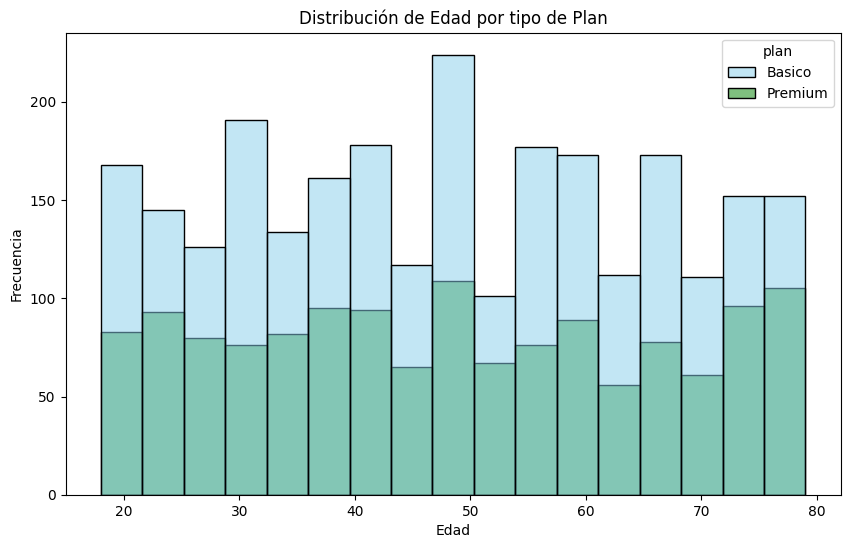

In [37]:
# Histograma para visualizar la edad (age)
# Luego crear el palette con los valores exactos


plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='age',
             hue="plan",
             palette=['skyblue','green']
             )                     

plt.title('Distribución de Edad por tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()




💡Insights: 
- Distribución de Edad por tipo de plan

No hay una forma claramente normal (campana) ni sesgos fuertes hacia jóvenes o mayores.
Esto sugiere que la edad está bastante dispersa y no concentrada en un segmento específico.
Hay fluctuaciones entre bins (normal en histogramas), pero no patrones estructurales fuertes.

El plan Básico tiene mayor frecuencia en todos los rangos de edad, es el plan dominante o más popular.
El plan Premium sigue un patrón muy similar, pero con menor volumen


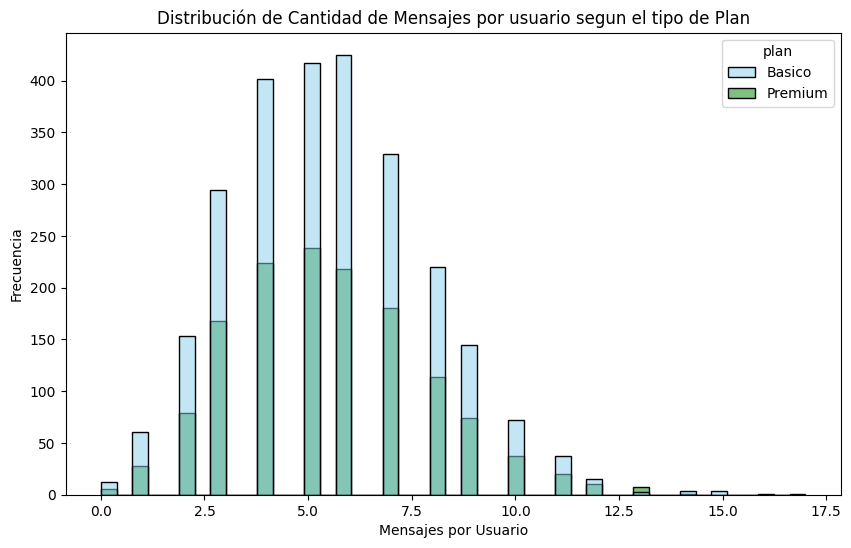

In [38]:
# Histograma para visualizar la cant_mensajes


plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='cant_mensajes',
             hue="plan",
             palette=['skyblue','green']
             )                     

plt.title('Distribución de Cantidad de Mensajes por usuario segun el tipo de Plan')
plt.xlabel('Mensajes por Usuario')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 

- La distribuación de ambos tipos de planes estan sesgados a la derecha

- Básico tiene mayor dispersión → usuarios desde muy baja hasta muy alta actividad.
Premium está más “contenido” → comportamiento más homogéneo.

La mayoría de usuarios envía pocos a medianos mensajes (≈3–7).
Hay una cola larga hacia la derecha con usuarios que envían muchos mensajes (10+), pero son pocos.

Hallazgo importante: los usuarios más activos no están en Premium

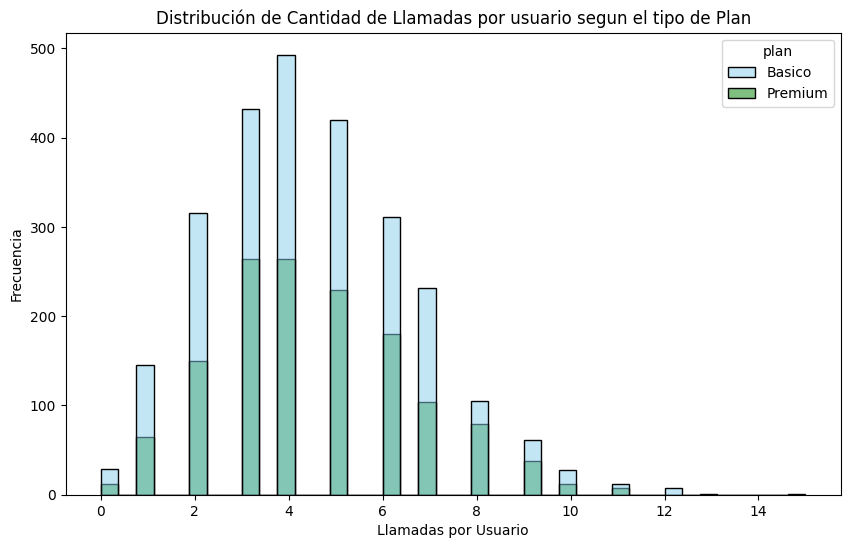

In [39]:
# Histograma para visualizar la cant_llamadas

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='cant_llamadas',
             hue="plan",
             palette=['skyblue','green']
             )                     

plt.title('Distribución de Cantidad de Llamadas por usuario segun el tipo de Plan')
plt.xlabel('Llamadas por Usuario')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución para ambos tipos de planes cuentan con sesgo a la derecha
- La mayoría de usuarios realiza entre 2 y 6 llamadas.
Existe una cola hacia la derecha (hasta ~12–15), pero con baja frecuencia.

El patrón se repite respecto a mensajes:
Los usuarios más intensivos (muchas llamadas) siguen estando más en Básico.
Premium no está capturando claramente a los usuarios de mayor uso.

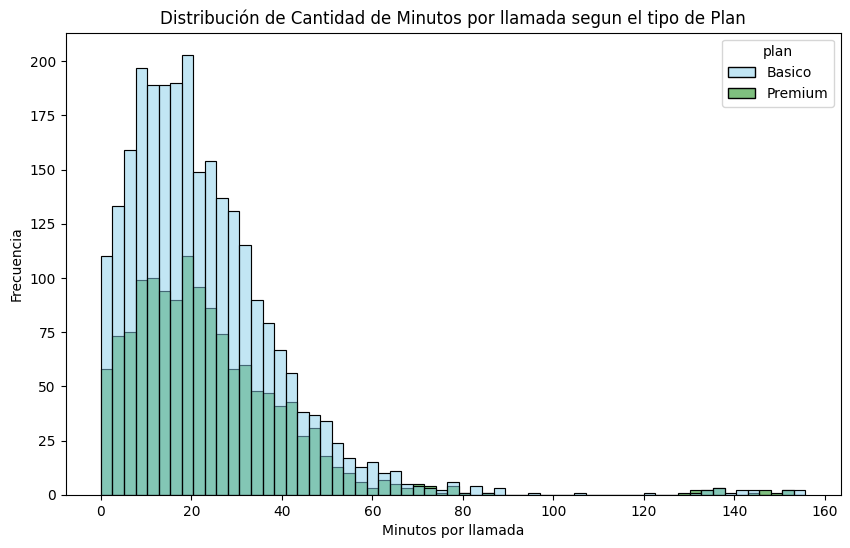

In [40]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='cant_minutos_llamada',
             hue="plan",
             palette=['skyblue','green']
             )                     

plt.title('Distribución de Cantidad de Minutos por llamada segun el tipo de Plan')
plt.xlabel('Minutos por llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Claramente asimétrica con sesgo hacia la derecha para ambos tipos de planes
Fuerte concentración en valores bajos:
La mayoría de llamadas duran entre 5 y 30 minutos.
Cola larga muy extendida:
Hay casos extremos de llamadas muy largas (hasta ~150 min)

Los usuarios que hacen llamadas muy largas están mayormente en Básico.
Premium parece tener usuarios con comportamiento más “controlado” o consistente.

Premium no está capturando valor de los usuarios más intensivos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

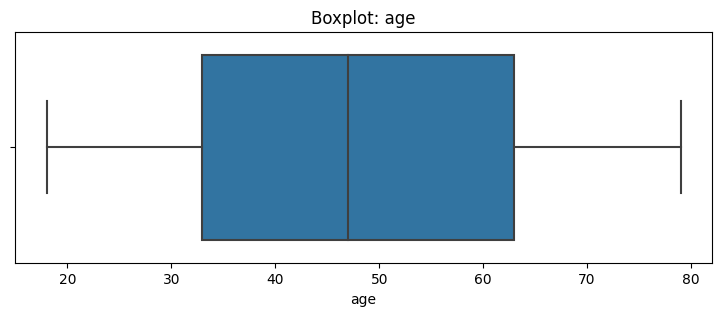

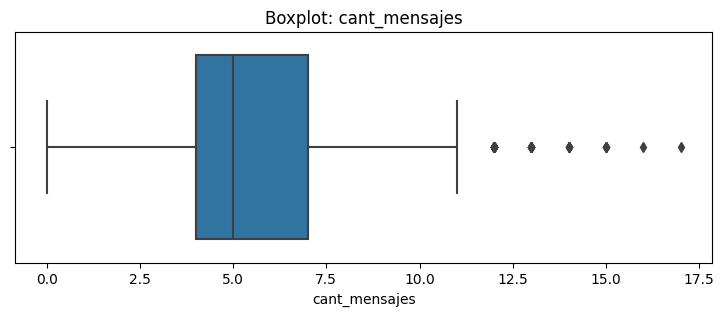

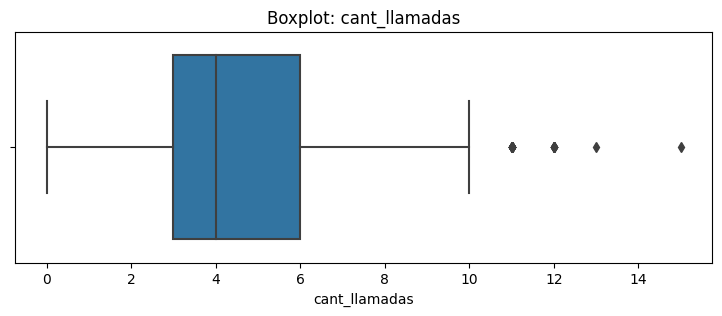

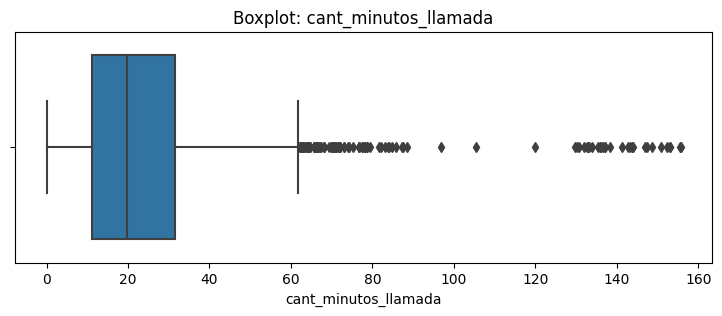

In [41]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age es la unica variable que no contiene outliers, el resto si

In [42]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for lim in columnas_limites:
    Q1= user_profile[lim].quantile(0.25)
    Q3= user_profile[lim].quantile(0.75)
    IQR= Q3-Q1
    upper= Q3+1.5*IQR
    print(lim, "IQR: ",IQR)
    print(lim, "upper: ", upper)
    print()



cant_mensajes IQR:  3.0
cant_mensajes upper:  11.5

cant_llamadas IQR:  3.0
cant_llamadas upper:  10.5

cant_minutos_llamada IQR:  20.295
cant_minutos_llamada upper:  61.8575



In [43]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener
Son usuarios valiosos (heavy users)
No distorsionan fuertemente la distribución
Eliminarlos te haría perder señal de comportamiento real

- cant_llamadas: mantener
Representan uso intensivo legítimo
No hay evidencia de errores o ruido extremo

- cant_minutos_llamada: mantener
Es un patron de negocio valido, es normal tener usuarios con uso extremo, las llamadas largas son comportamiento legitimo, no es un error de medicion
eliminarlos = perder información de segmentos importantes, podrían ser usuarios de negocio o con necesidades específicas
Son candidatos perfectos para upselling a Premium, Pueden generar ingresos adicionales por excesos


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [66]:
# Crear columna grupo_uso


def segmentacion_uso(row):
    mensajes=row["cant_mensajes"]
    llamadas=row["cant_llamadas"]

    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Error de Datos"

    if llamadas < 5 and mensajes < 5:
        return "Bajo Uso"
        
    elif llamadas < 10 and mensajes < 10:
        return "Uso Medio"
    else: 
        return "Alto Uso"



user_profile["grupo_uso"]=user_profile.apply(segmentacion_uso, axis=1)




In [67]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso Medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo Uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [68]:
# Crear columna grupo_edad
def segmentacion_edad(row):
    edad=row["age"]

    if pd.isna(edad):
        return "Error de Datos"

    if edad < 30:
        return "Joven"
        
    elif edad < 60:
        return "Adulto"
    else: 
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(segmentacion_edad, axis=1)




In [69]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso Medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

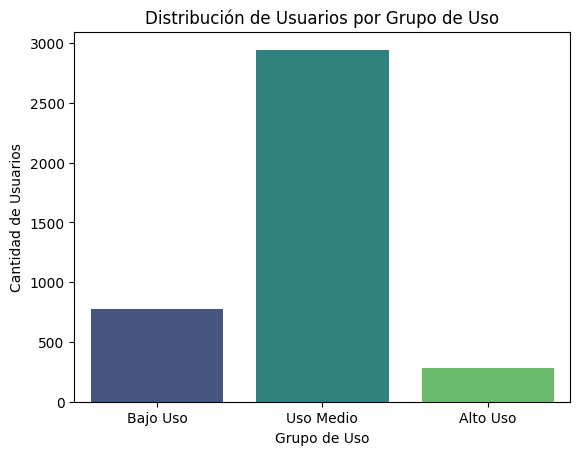

In [74]:

sns.countplot(data=user_profile, x='grupo_uso', 
              order=['Bajo Uso', 'Uso Medio', 'Alto Uso'],
              palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

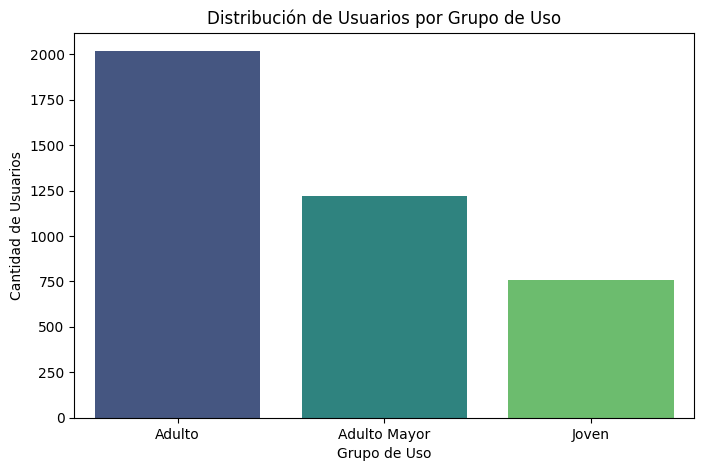

In [71]:
# Visualización de los segmentos por edad



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**
En el dataset users:

Valores sentinel en edad: -999 (representaba valores inválidos)
Valores sentinel en ciudad: "?" (96 registros = 2.4% del total)
Fechas imposibles: 40 registros con año 2026 (1% del total)
Valores nulos en ciudad: 469 registros (11.7%)
Valores nulos en churn_date: 3,534 registros (88.3% - normal, indica clientes activos)
En el dataset usage:

Valores nulos en date: 50 registros (0.12%)
Valores nulos en duration: 22,076 registros (55.19% - MAR, corresponden a mensajes)
Valores nulos en length: 17,896 registros (44.74% - MAR, corresponden a llamadas)

🔍 **Segmentos por Edad**

Por Edad:

Jóvenes (< 30 años)
Adultos (30-59 años)
Adultos Mayores (≥ 60 años)


📊 **Segmentos por Nivel de Uso**

Por Nivel de Uso:

Bajo Uso: < 5 llamadas Y < 5 mensajes
Uso Medio: < 10 llamadas Y < 10 mensajes
Alto Uso: ≥ 10 llamadas O ≥ 10 mensajes


➡️ Esto sugiere que ...
Usuarios de Alto Uso con Plan Básico:

Representan una oportunidad de upselling inmediata
Ya demuestran alta demanda de servicios
Están "subsidiando" su uso extra con tarifas por exceso
Usuarios Premium en general:

Mayor valor por cliente (plan más caro)
Comportamiento más predecible y estable

**Outliers y sus implicaciones**
1. Cantidad de mensajes (límite superior: 11.5, máximo: 17)

Usuarios que envían más de 11-12 mensajes representan uso extremo
Estos heavy users están principalmente en plan Básico
Implicación: Están pagando excesos innecesarios cuando podrían estar en Premium
2. Cantidad de llamadas (límite superior: 10.5, máximo: 15)

Usuarios con más de 10-11 llamadas son outliers
También concentrados en plan Básico
Implicación: Oportunidad de upselling perdida
3. Minutos de llamada (límite superior: 61.9, máximo: 155.7)

Usuarios con llamadas extremadamente largas (hasta 2.5 horas)
Comportamiento legítimo de negocio o necesidades específicas
Implicación: Segmento premium no capturado, potencial para planes corporativos
Conclusión clave: Los usuarios más valiosos (heavy users) están mal segmentados en planes básicos, generando ingresos por excesos pero sin fidelización.

💡 **Recomendaciones**
1. Crear plan "Power User"

Para usuarios con 8+ llamadas O 8+ mensajes
Incluir más minutos y mensajes que Premium actual
Precio intermedio entre Premium y costos por exceso
2. Implementar alertas de upselling automático

Detectar usuarios Básico que excedan límites 3 meses consecutivos
Ofrecer migración a Premium con descuento temporal
3. Plan corporativo/empresarial

Para outliers extremos (150+ minutos, 15+ llamadas)
Incluir servicios adicionales (conferencias, roaming)
Modelo de facturación diferenciado
4. Optimizar plan Premium actual

Aumentar límites para capturar mejor a usuarios de "Alto Uso"
Agregar beneficios diferenciadores (soporte prioritario, datos extra)
5. Segmentación por edad

Planes familiares para Adultos Mayores
Planes estudiantiles para Jóvenes
Descuentos por lealtad basados en tiempo de registro

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`